# Titanic Machine Learning using R

In [141]:
#importing libraries required
library(dplyr)
library(ggplot2)
library(caret)
# install.packages("corrplot")
library(corrplot)


The RMS Titanic carried approximately 2,224 people on board, including passengers and crew, during its maiden voyage in April 1912. This number includes about 1,316 passengers and 908 crew members. The dataset here refers to the passengers records. the voyage was from Southampton, England, to New York City, USA.

<img src="TitanicRoute.svg.png" width="600" height="400">


## Loading the dataset

In [142]:
df_train<-read.csv("train.csv")
df_test<-read.csv("test.csv")
head(df_train)
head(df_test)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,,S
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,,S
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,,S
6,6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,,Q


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,,Q
2,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,,S
3,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,,Q
4,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,,S
5,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,,S
6,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,,S


the above dataset is comprised of datasets as train and test as obtained from the kaggle competition dataset of " Titanic - ML from Disaster" <br>
https://www.kaggle.com/c/titanic/data?select=train.csv <br>
the target variable information (ground truth) for the test dataset is not given here so we can also use the r library to include it's dataset for a comprehensive analysis.

In [143]:
dim(df_train)
dim(df_test)

[1] 891  12

[1] 418  11

### Attempting to use the titanic dataset using the titanic package in R to see if we can have survival rates for test data as well

In [144]:
# install.packages("titanic")

library("titanic")

# Load the training dataset
data("titanic_test")

head(titanic_train)
head(titanic_test)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,,S
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,,S
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,,S
6,6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,,Q


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,,Q
2,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,,S
3,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,,Q
4,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,,S
5,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,,S
6,897,3,"Svensson, Mr. Johan Cervin",male,14.0,0,0,7538,9.2250,,S


the survived column is taken as the "y"( target variable) to be opted out of the test dataset. we've also found that the datasets available in R and kaggle as identical with no survived column provided for the test column. <br>

This also hinders our ability to combine the two train and test datasets for a comprehensive EDA as the survived column for the test col will be null. 

In [145]:
str(df_train)

'data.frame':	891 obs. of  12 variables:
 $ PassengerId: int  1 2 3 4 5 6 7 8 9 10 ...
 $ Survived   : int  0 1 1 1 0 0 0 0 1 1 ...
 $ Pclass     : int  3 1 3 1 3 3 1 3 3 2 ...
 $ Name       : chr  "Braund, Mr. Owen Harris" "Cumings, Mrs. John Bradley (Florence Briggs Thayer)" "Heikkinen, Miss. Laina" "Futrelle, Mrs. Jacques Heath (Lily May Peel)" ...
 $ Sex        : chr  "male" "female" "female" "female" ...
 $ Age        : num  22 38 26 35 35 NA 54 2 27 14 ...
 $ SibSp      : int  1 1 0 1 0 0 0 3 0 1 ...
 $ Parch      : int  0 0 0 0 0 0 0 1 2 0 ...
 $ Ticket     : chr  "A/5 21171" "PC 17599" "STON/O2. 3101282" "113803" ...
 $ Fare       : num  7.25 71.28 7.92 53.1 8.05 ...
 $ Cabin      : chr  "" "C85" "" "C123" ...
 $ Embarked   : chr  "S" "C" "S" "S" ...


For the above reasons, we can use the train dataset for EDA purposes with 891 records across 12 columns for analysis that consider survived column and the full combined dataset of both train and test for comprehensive analysis. 

### Merging the data for EDA

In [146]:
# merging the train and test datasets to create one comprehensive datasets. The records comming from test dataset will have empty for survived
titanic<-bind_rows(df_train,df_test)

tail(titanic)
dim(titanic)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1304,1304,NA,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,,S
1305,1305,NA,3,"Spector, Mr. Woolf",male,NA,0,0,A.5. 3236,8.0500,,S
1306,1306,NA,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1307,1307,NA,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,,S
1308,1308,NA,3,"Ware, Mr. Frederick",male,NA,0,0,359309,8.0500,,S
1309,1309,NA,3,"Peter, Master. Michael J",male,NA,1,1,2668,22.3583,,C


[1] 1309   12

## Exploratory Data Analysis

In [147]:
# Set plot size
options(repr.plot.width = 10, repr.plot.height = 8) 

In [148]:
colnames(titanic)

[1] "PassengerId" "Survived"    "Pclass"      "Name"        "Sex"        
 [6] "Age"         "SibSp"       "Parch"       "Ticket"      "Fare"       
[11] "Cabin"       "Embarked"

 **Dataset column information**

| Variable   | Definition                        | Key                              |
|------------|------------------------------------|-----------------------------------|
| survival   | Survival                          | 0 = No, 1 = Yes                  |
| pclass     | Ticket class                      | 1 = 1st, 2 = 2nd, 3 = 3rd        |
| sex        | Sex                               |                                   |
| Age        | Age in years                      |                                   |
| sibsp      | # of siblings / spouses aboard    |                                   |
| parch      | # of parents / children aboard    |                                   |
| ticket     | Ticket number                     |                                   |
| fare       | Passenger fare                    |                                   |
| cabin      | Cabin number                      |                                   |
| embarked   | Port of Embarkation               | C = Cherbourg, Q = Queenstown, S = Southampton |



In [149]:
# summary statistics for all numerical columns
summary(titanic)

  PassengerId      Survived          Pclass          Name          
 Min.   :   1   Min.   :0.0000   Min.   :1.000   Length:1309       
 1st Qu.: 328   1st Qu.:0.0000   1st Qu.:2.000   Class :character  
 Median : 655   Median :0.0000   Median :3.000   Mode  :character  
 Mean   : 655   Mean   :0.3838   Mean   :2.295                     
 3rd Qu.: 982   3rd Qu.:1.0000   3rd Qu.:3.000                     
 Max.   :1309   Max.   :1.0000   Max.   :3.000                     
                NA's   :418                                        
     Sex                 Age            SibSp            Parch      
 Length:1309        Min.   : 0.17   Min.   :0.0000   Min.   :0.000  
 Class :character   1st Qu.:21.00   1st Qu.:0.0000   1st Qu.:0.000  
 Mode  :character   Median :28.00   Median :0.0000   Median :0.000  
                    Mean   :29.88   Mean   :0.4989   Mean   :0.385  
                    3rd Qu.:39.00   3rd Qu.:1.0000   3rd Qu.:0.000  
                    Max.   :80.00   Max.  

from passenger data across 1309 rows, key findings are <br>
mean age of a passenger on board: 29.88 -> around 30 years of age. <br>
mean passenger fare : 33.295 British pounds (£)

In [150]:
# survival rate of all passengers across the training dataset
table(df_train$Survived) #because we have survival data for only the training dataset
survival_rate <- (sum(df_train$Survived == 1, na.rm = TRUE) / length(df_train$Survived)) * 100

print(paste(round(survival_rate, 2), "% of passengers survived"))


  0   1 
549 342 

[1] "38.38 % of passengers survived"


#### Age Distribution

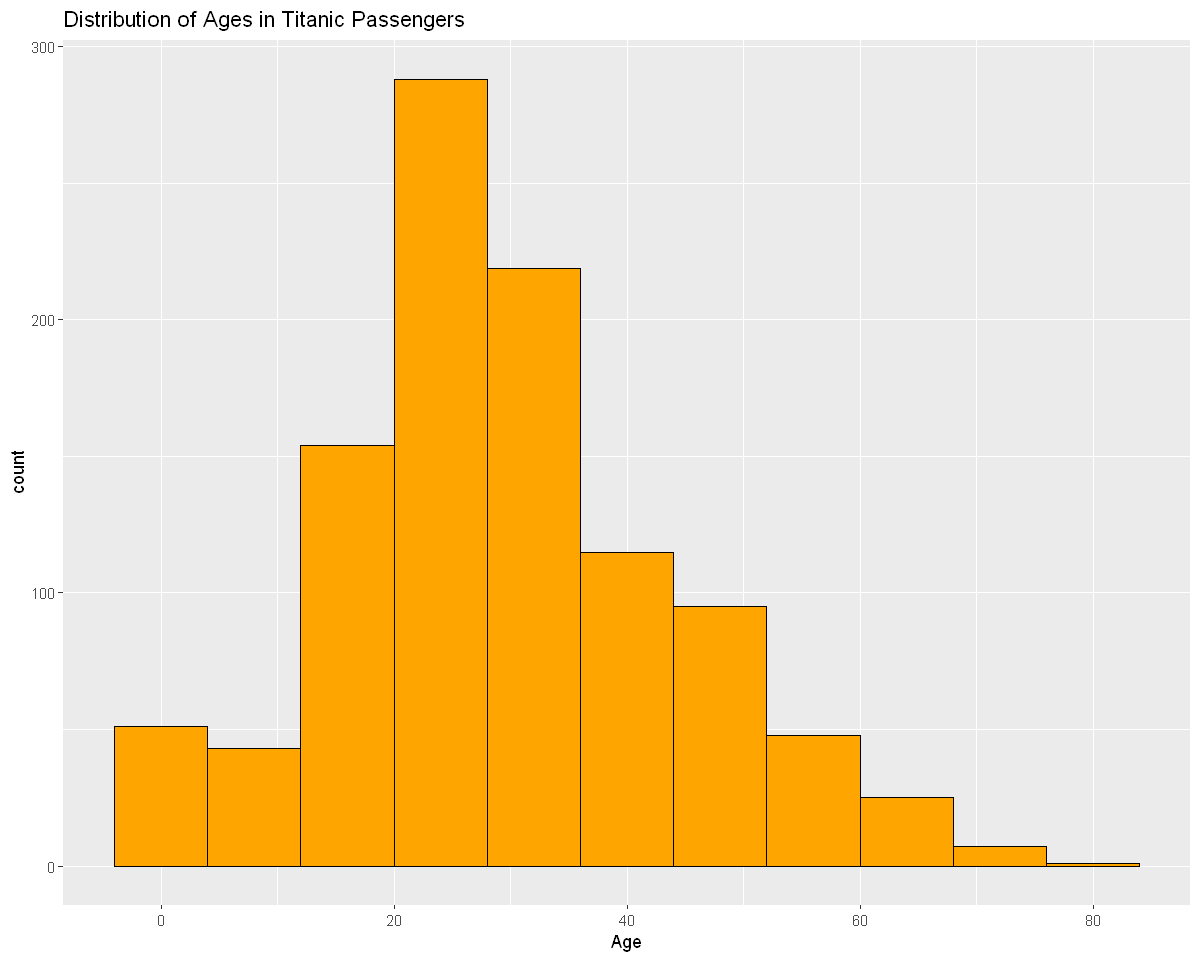

In [151]:
#plotting for age distribution
ggplot(titanic, aes(x=Age))+
geom_histogram(binwidth=8,fill="orange", color="black",na.rm = TRUE)+
labs(title="Distribution of Ages in Titanic Passengers") #na.rm removes all NA values

In [152]:
summary(titanic$Age)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   0.17   21.00   28.00   29.88   39.00   80.00     263 

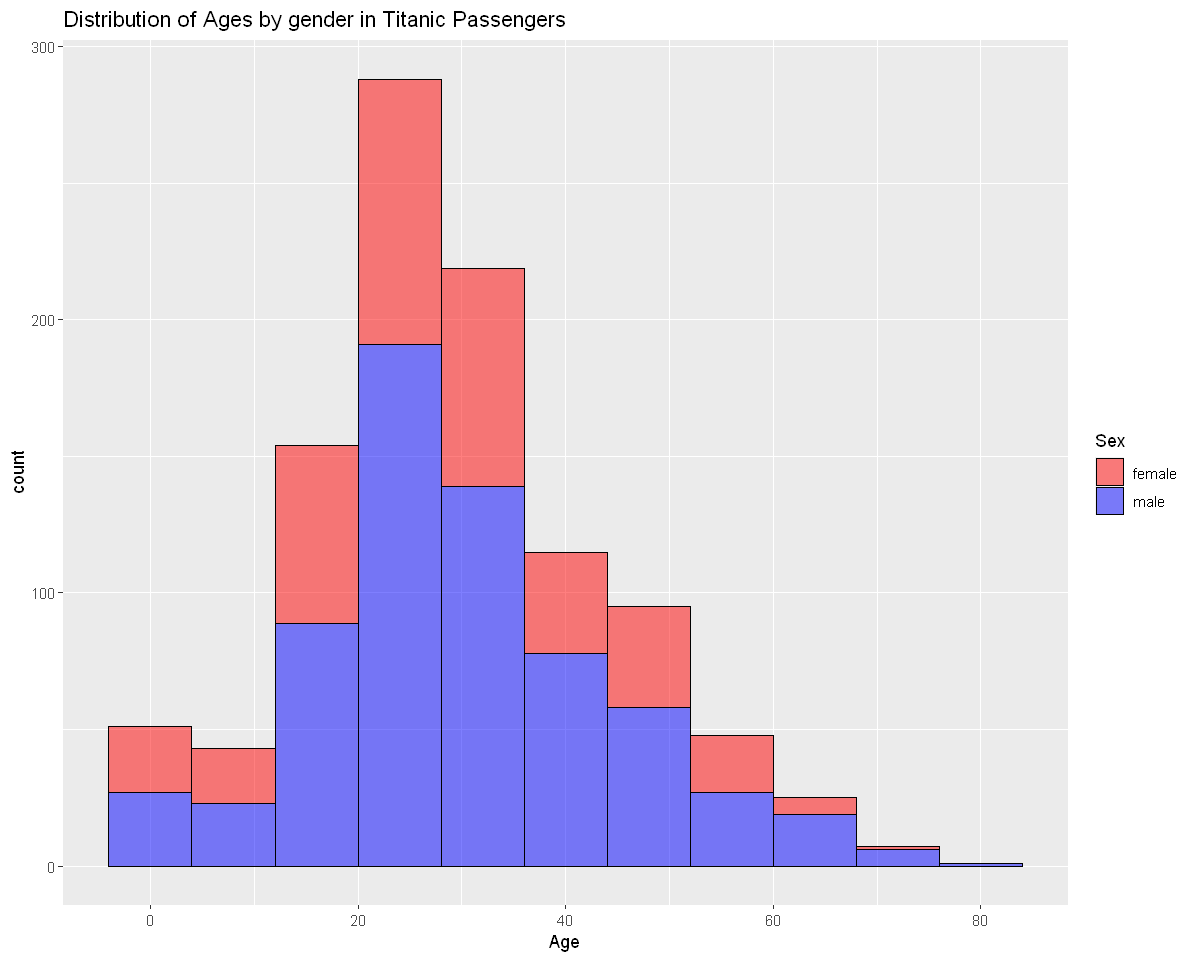

In [153]:
ggplot(titanic, aes(x=Age,  fill=Sex))+
geom_histogram(binwidth=8,alpha=0.5, color="black",na.rm = TRUE)+
scale_fill_manual(values = c("male" = "blue", "female" = "red")) +
labs(title="Distribution of Ages by gender in Titanic Passengers")

#### Gender Distribution

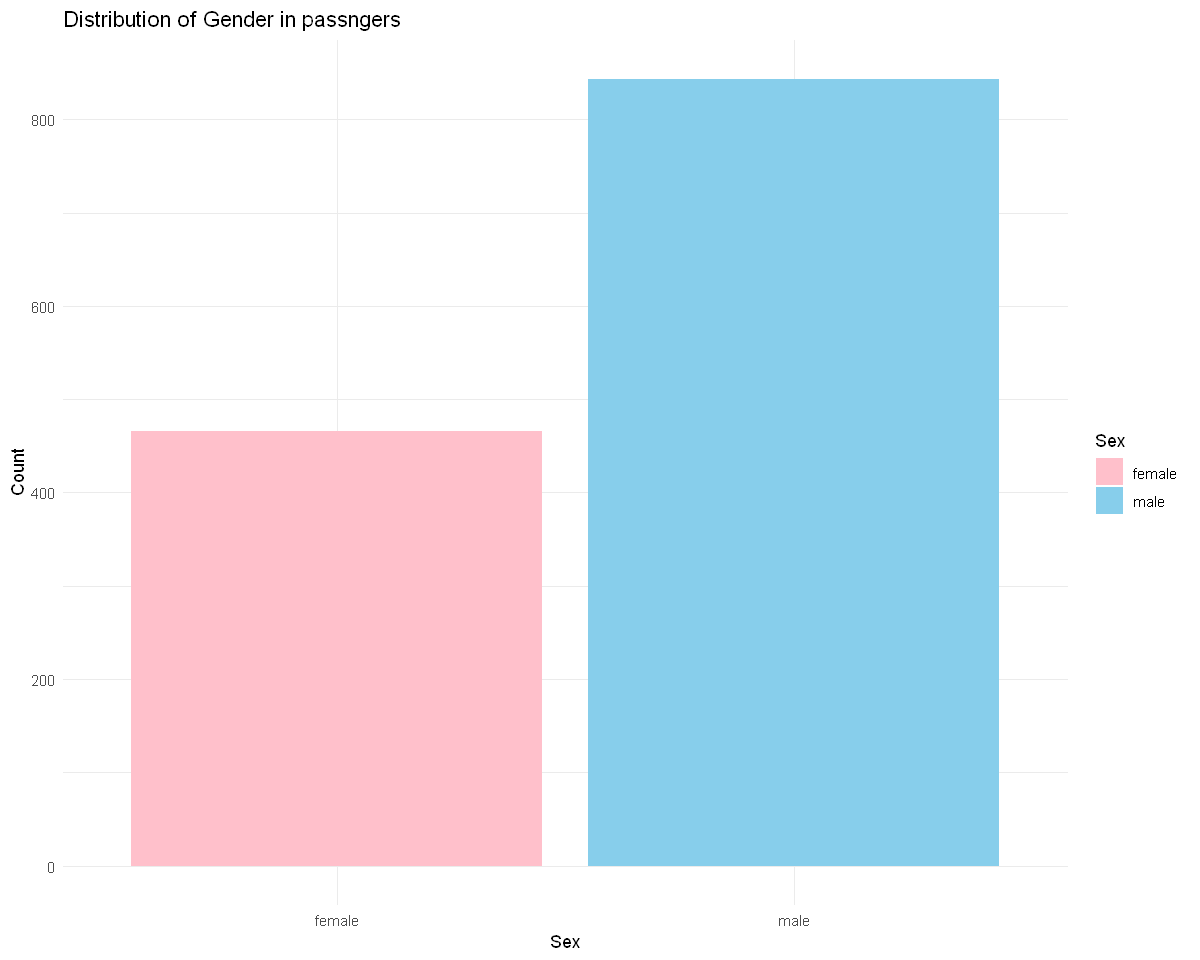

In [154]:
ggplot(titanic, aes(x = Sex, fill = Sex)) +
  geom_bar() +
  labs(title = "Distribution of Gender in passngers", x = "Sex", y = "Count") +
  scale_fill_manual(values = c("male" = "skyblue", "female" = "pink")) +
  theme_minimal()

Survival rates across genders

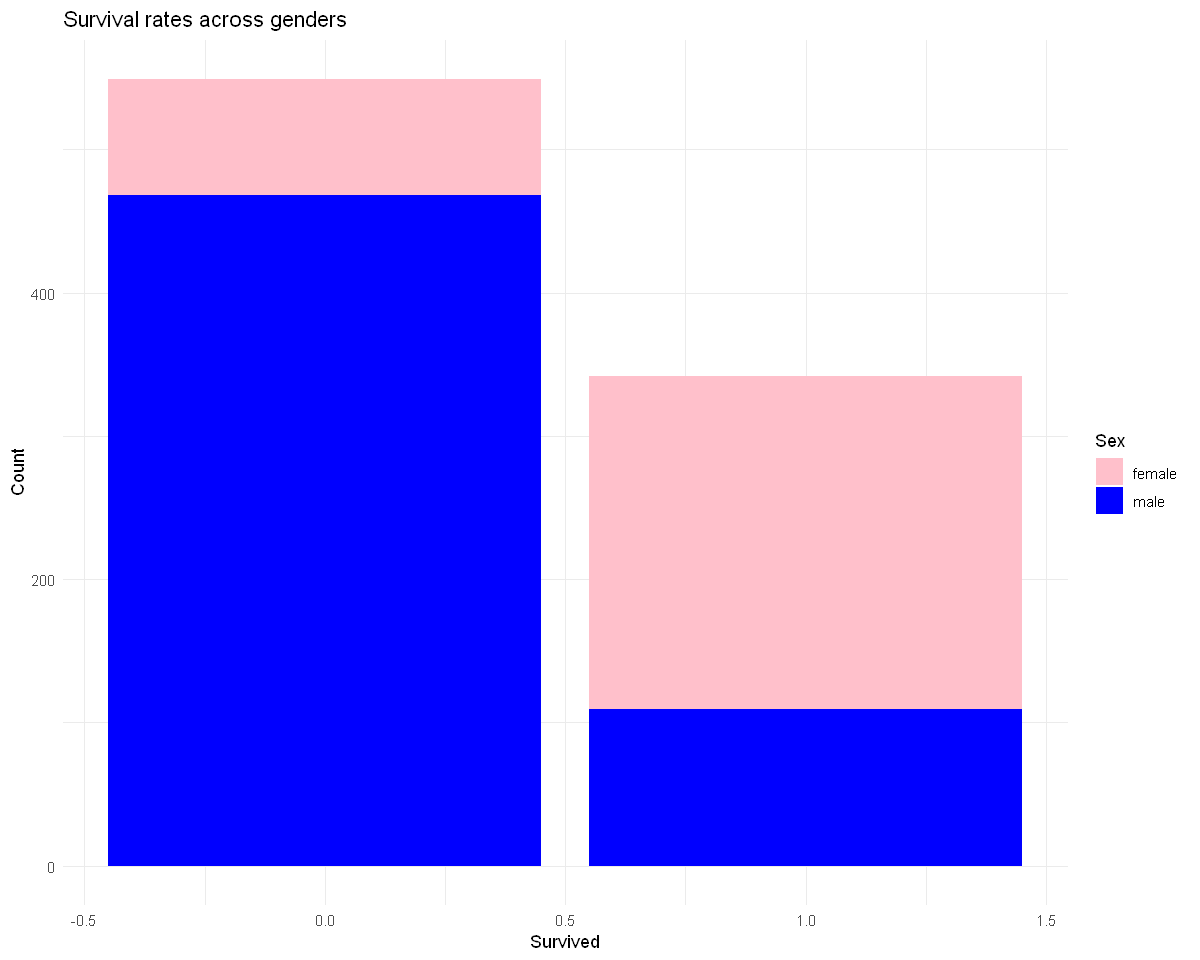

In [155]:
ggplot(df_train, aes(x = Survived, fill = Sex)) +
  geom_bar() +
  labs(title = "Survival rates across genders", x = "Survived", y = "Count") +
  theme_minimal() +
  scale_fill_manual(values = c("male" = "blue", "female" = "pink"))

In [156]:
# Logical vectors for filtering
women <- (df_train$Sex == 'female')
men <- (df_train$Sex == 'male')

# Subset data frames
women_survived <- df_train[women, ]
men_survived <- df_train[men, ]


# Using nrow() to get the number of rows in the subset
women_survive <- sum(women_survived$Survived == 1, na.rm = TRUE) / nrow(women_survived) * 100
men_survive <- sum(men_survived$Survived == 1, na.rm = TRUE) / nrow(men_survived) * 100


print(paste(round(women_survive, 2), "% of women on board the ship survived"))
print(paste(round(men_survive, 2), "% of men on board the ship survived"))

[1] "74.2 % of women on board the ship survived"
[1] "18.89 % of men on board the ship survived"


#### Passenger Class Distribution

In [157]:
table(titanic$Pclass)


  1   2   3 
323 277 709 

Most of the passengers are taking the passenger class 3 with roughly equal numbers are on board the ship for class 1 and 2.

Survival rates from the training datasets of 891 records reveal 38.38% of survival rate

Most of the passengers in the training data has not survived with 342 survival. More females have survived than males though the ratio of males and females board the ship

Passenger Class distribution based on survival rate

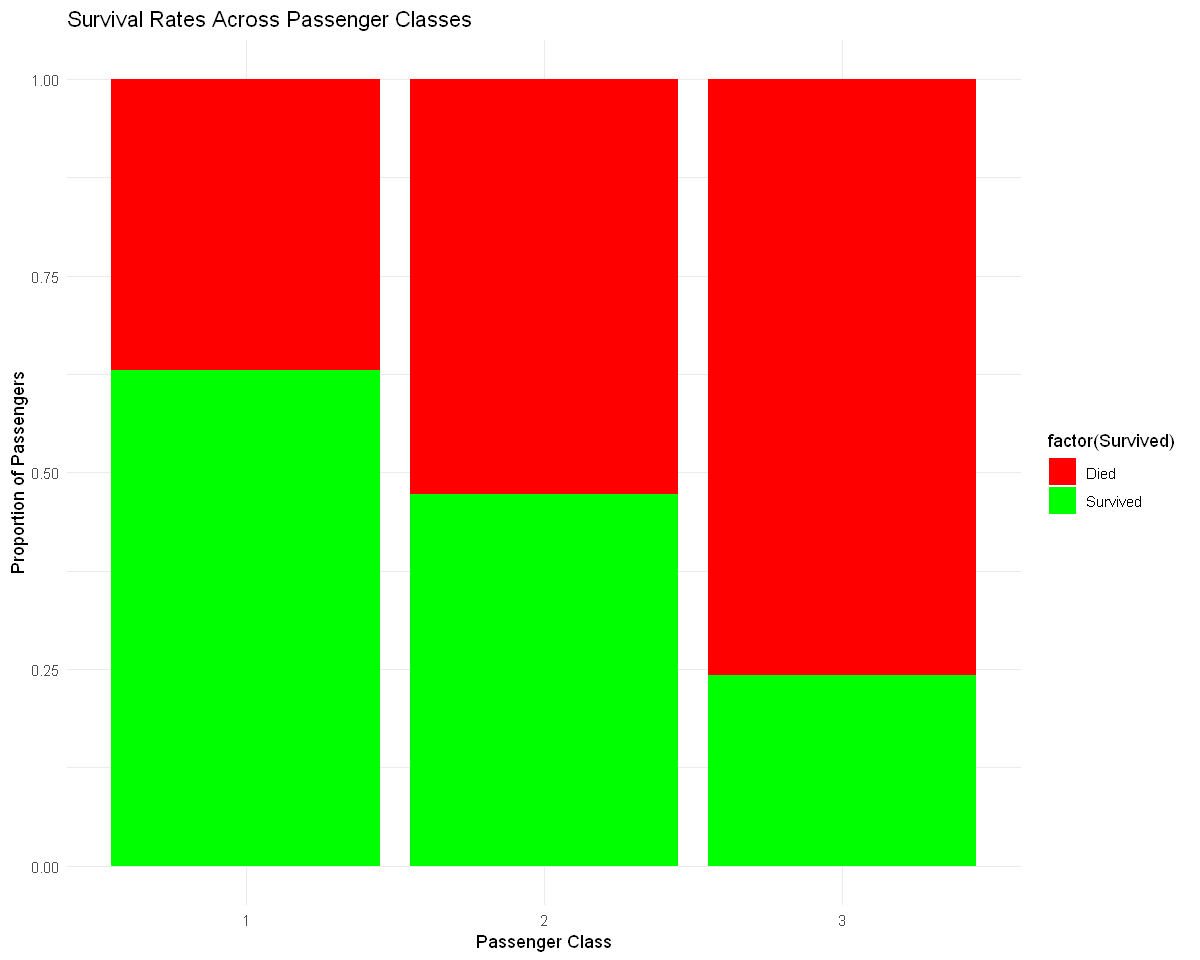

In [158]:
#proportional bar plots to,
# Plot survival rates across different passenger classes
ggplot(df_train, aes(x = factor(Pclass), fill = factor(Survived))) + 
  geom_bar(position = "fill") +  # "fill" stacks the bars to show proportions
  labs(title = "Survival Rates Across Passenger Classes", 
       x = "Passenger Class", 
       y = "Proportion of Passengers") +
  scale_fill_manual(values = c("0" = "red", "1" = "green"), 
                    labels = c("Died", "Survived")) +
  theme_minimal()

#### Embarked location


      C   Q   S 
  2 270 123 914 

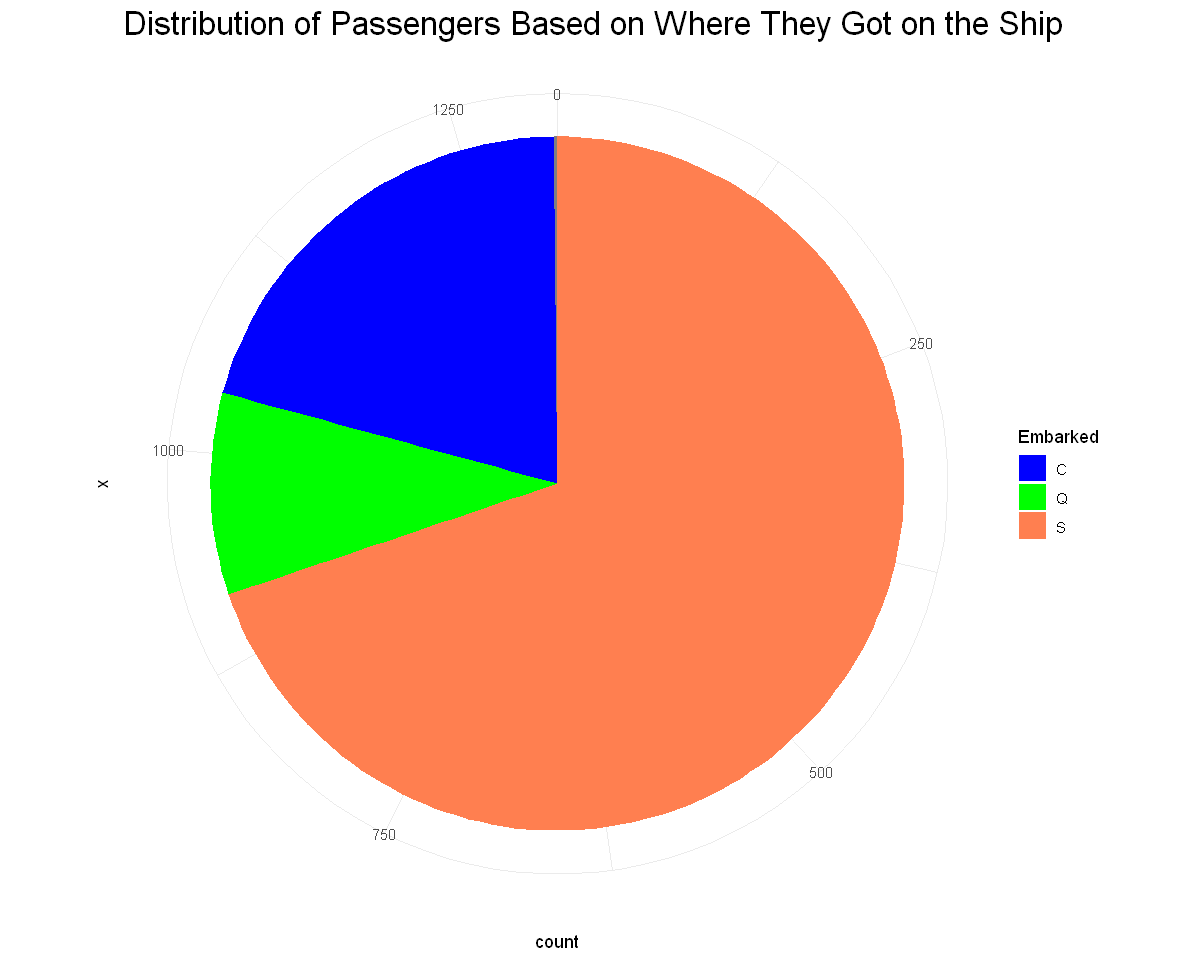

In [159]:
titanic %>%
  ggplot(aes(x = "", fill = Embarked)) +  
  geom_bar(width = 1, show.legend = TRUE) +  
  coord_polar(theta = 'y') +  # Convert the bar chart to a pie chart
  labs(title = "Distribution of Passengers Based on Where They Got on the Ship") +
 scale_fill_manual(values = c("C" = "blue", "Q" = "green", "S" = "coral")) +  
  theme_minimal()+
theme(plot.title = element_text(size = 20))

table(titanic$Embarked)

C = Cherbourg, Q = Queenstown, S = Southampton <br>
Thus, over 2/3 of the passengers have boarded the ship from southampton UK (where ship set it's sails from) followed by Cherbourg, France and Queenstown in Ireland 

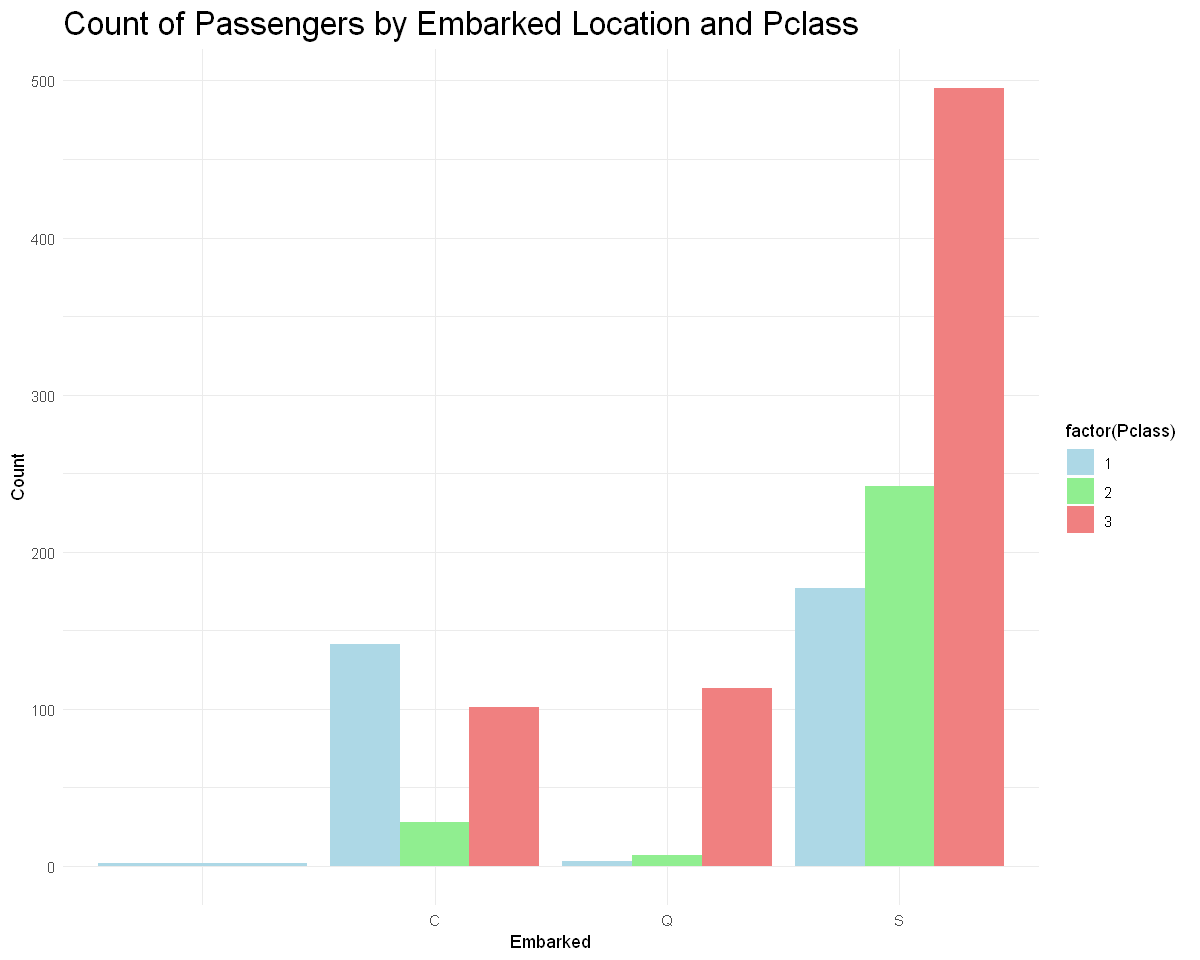

In [160]:
ggplot(titanic, aes(x = Embarked, fill = factor(Pclass))) +
  geom_bar(position = "dodge") +  # 'dodge' makes bars for different Pclass appear side by side
  labs(title = "Count of Passengers by Embarked Location and Pclass", 
       x = "Embarked", y = "Count") +
  scale_fill_manual(values = c("1" = "lightblue", "2" = "lightgreen", "3" = "lightcoral")) +  # Customize colors for Pclass
  theme_minimal()+
theme(plot.title = element_text(size = 20))

more of a proportion of passengers from France have choosen 1st and 2nd class compared to british and irish passengers.

#### Fare

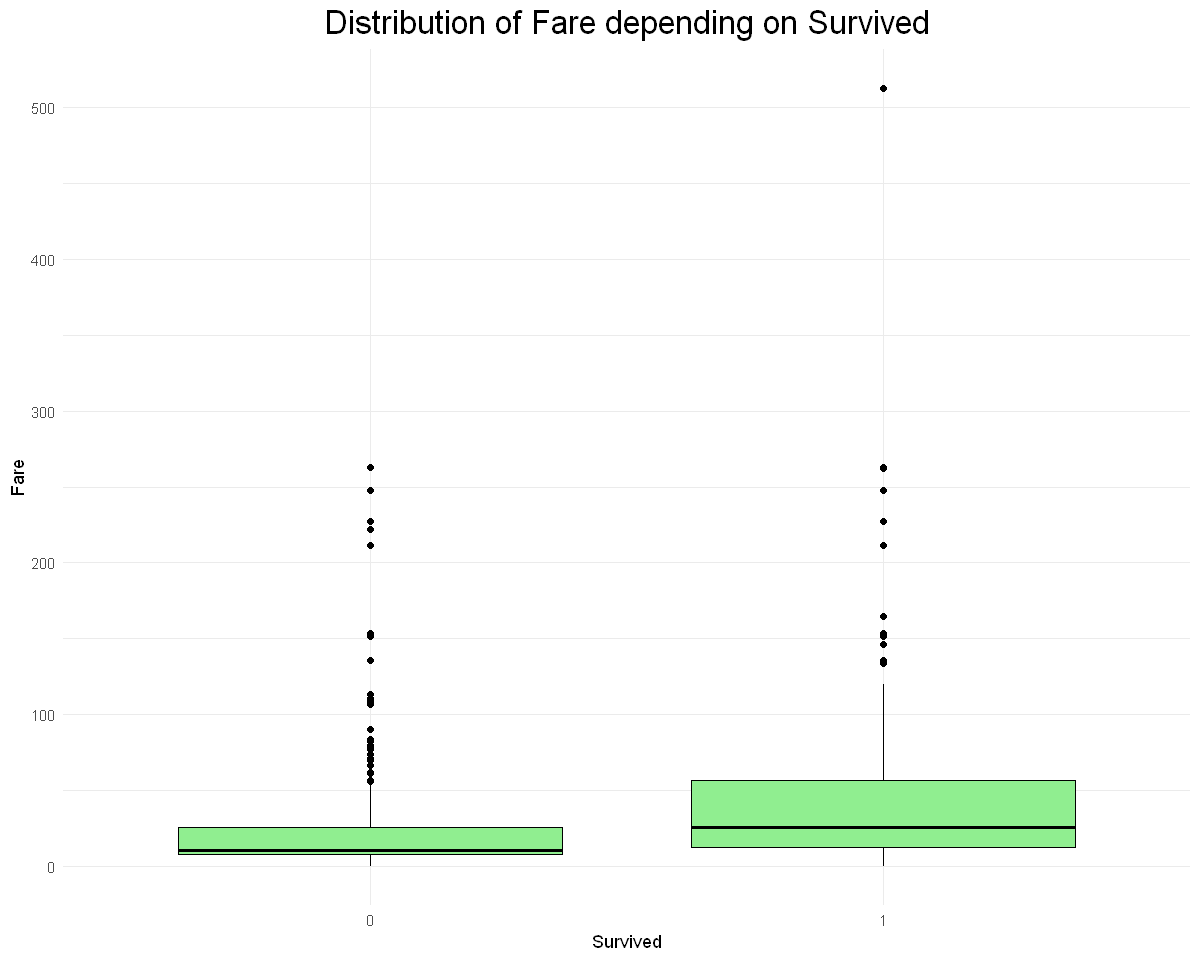

In [161]:
ggplot(df_train, aes(x = factor(Survived), y = Fare)) +
  geom_boxplot(fill = "lightgreen", color = "black", na.rm = TRUE) + 
  labs(title = "Distribution of Fare depending on Survived", 
       x = "Survived", y = "Fare") +  # Add axis labels and title
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, vjust = 1.02, size = 20))

we can conclude that the passenger class has been a deciding factor on whether the passengers survived or not. 

In [162]:
# Get the number of NA values for each column
colSums(is.na(titanic)) #colsums sums up the true and false values

#empty values for cabin and embarked
sum(titanic$Cabin == "")
sum(titanic$Embarked =="")

PassengerId    Survived      Pclass        Name         Sex         Age 
          0         418           0           0           0         263 
      SibSp       Parch      Ticket        Fare       Cabin    Embarked 
          0           0           0           1           0           0

[1] 1014

[1] 2

In [163]:
#replacing the missing fare value just for EDA purposes (not applied to original train and test data for now) 
mean_fare <- mean(titanic$Fare, na.rm = TRUE) #gettting the mean fare

# Replace NA values with the mean
titanic$Fare[is.na(titanic$Fare)] <- mean_fare

In [164]:
# Group by Passenger class and Embarked port and calculate the average Fare
grouped_data <- titanic %>%
  group_by(Pclass, Embarked) %>%

summarise(Average_Fare = mean(Fare), .groups = "keep")
print(grouped_data)

# A tibble: 10 × 3
# Groups:   Pclass, Embarked [10]
   Pclass Embarked Average_Fare
    <int> <chr>           <dbl>
 1      1 ""               80  
 2      1 "C"             107. 
 3      1 "Q"              90  
 4      1 "S"              72.1
 5      2 "C"              23.3
 6      2 "Q"              11.7
 7      2 "S"              21.2
 8      3 "C"              11.0
 9      3 "Q"              10.4
10      3 "S"              14.5


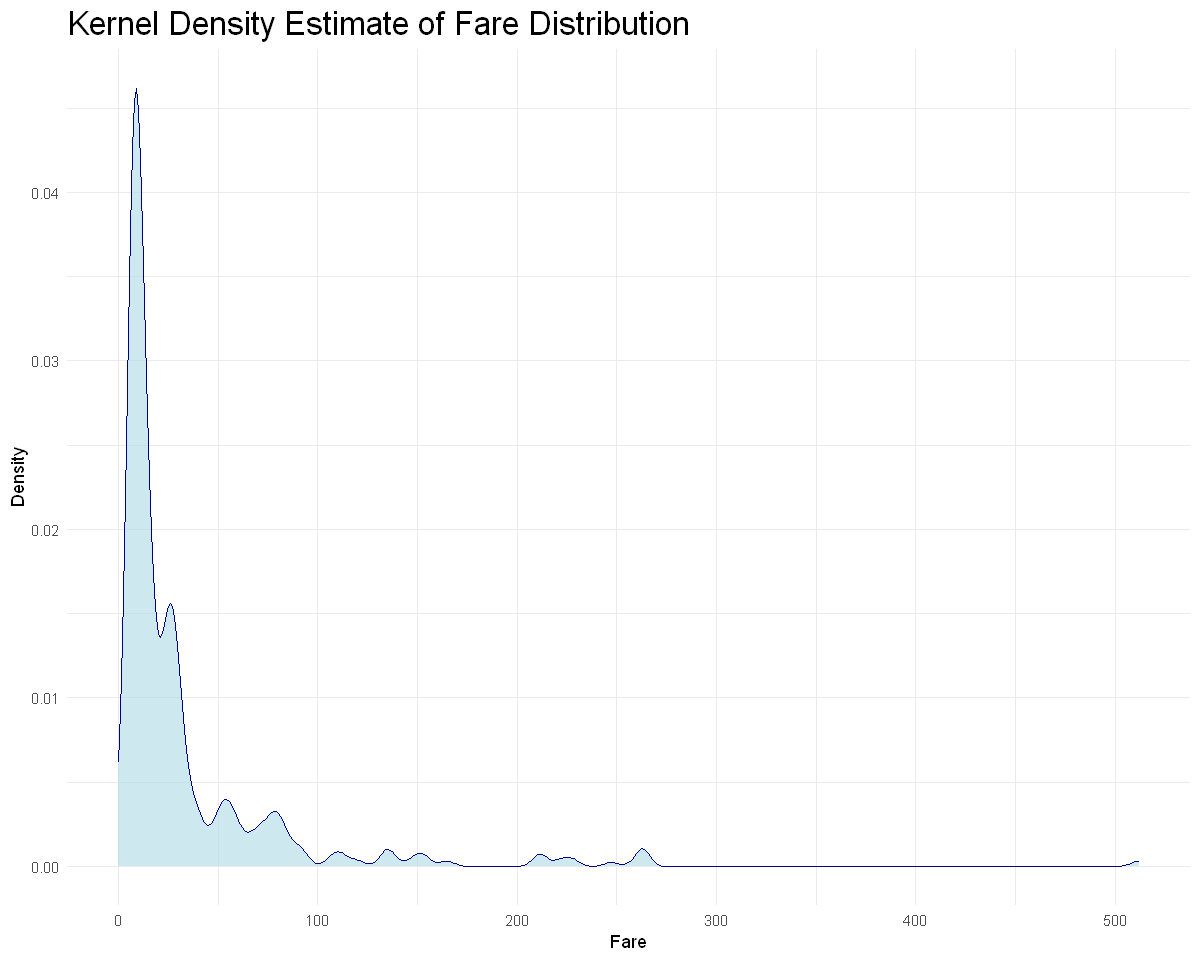

In [165]:
ggplot(titanic, aes(x = Fare)) +
  geom_density(fill = "lightblue", color = "darkblue", alpha = 0.6, na.rm = TRUE) + 
  labs(
    title = "Kernel Density Estimate of Fare Distribution",
    x = "Fare",
    y = "Density"
  ) +
  theme_minimal() +
theme(plot.title=element_text(size=20))

Ticket pricing according to: https://highseascruising.com/how-much-was-a-ticket-on-the-titanic/

|Class	|Price in 1912 (£)|
|-------|-----------------|
|First Class Suite	|£870	|
|First Class Berth	|£30	|
|Second Class	|£12	|
|Third Class	|£7	|

what we get is a heavily skewed distribution

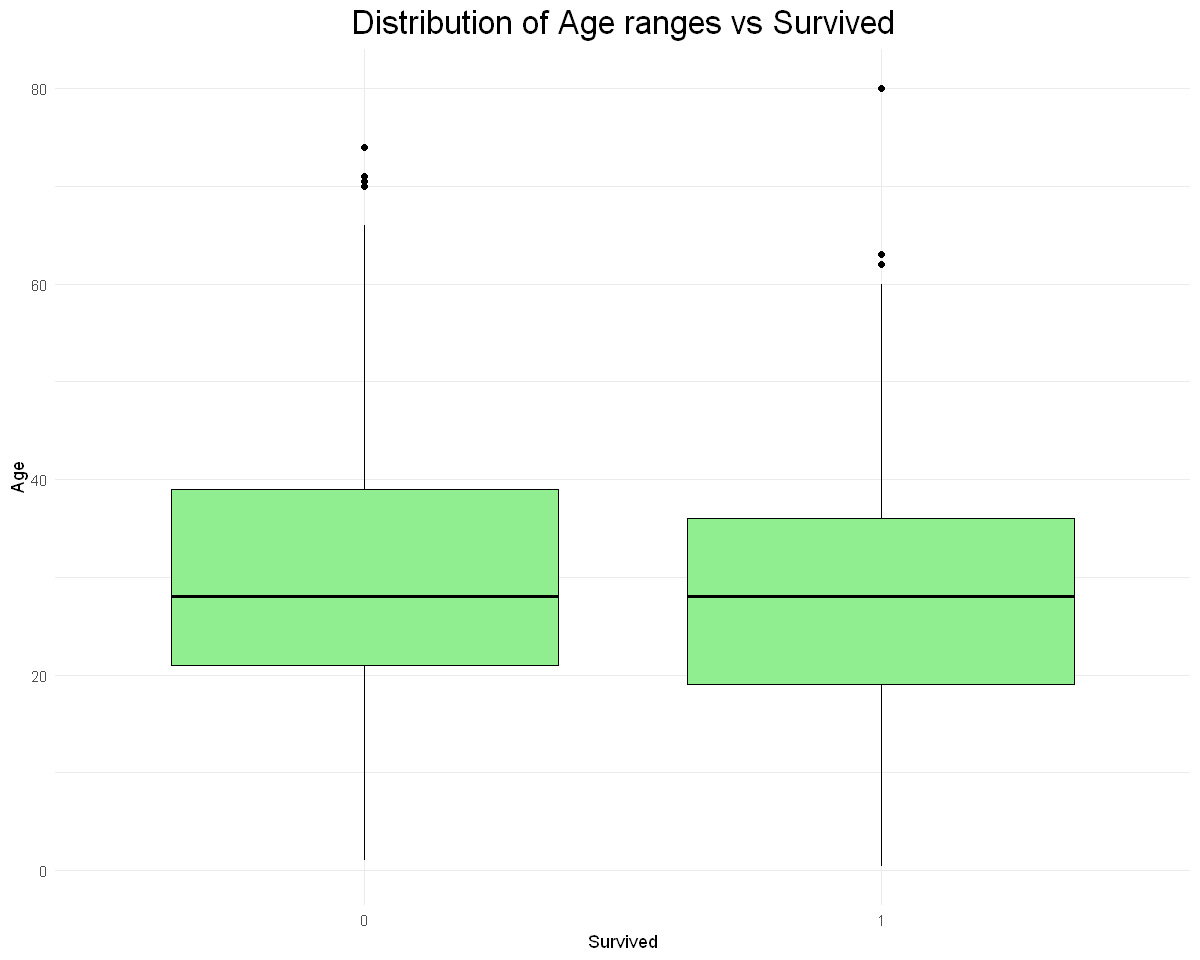

In [166]:
ggplot(df_train, aes(x = factor(Survived), y = Age)) +
  geom_boxplot(fill = "lightgreen", color = "black", na.rm = TRUE) + 
  labs(title = "Distribution of Age ranges vs Survived", 
       x = "Survived", y = "Age") +  # Add axis labels and title
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, vjust = 1.02, size = 20))

#### Under 18 passengers

In [167]:
under_18 <- titanic %>% 
  filter(Age < 18)
  
count_under_18 <- nrow(under_18)

print(paste(count_under_18, "of passengers were below 18 years old children"))
print(paste(round(count_under_18 / nrow(titanic) * 100, 2), " % of passengers are thus underage "))


[1] "154 of passengers were below 18 years old children"
[1] "11.76  % of passengers are thus underage "


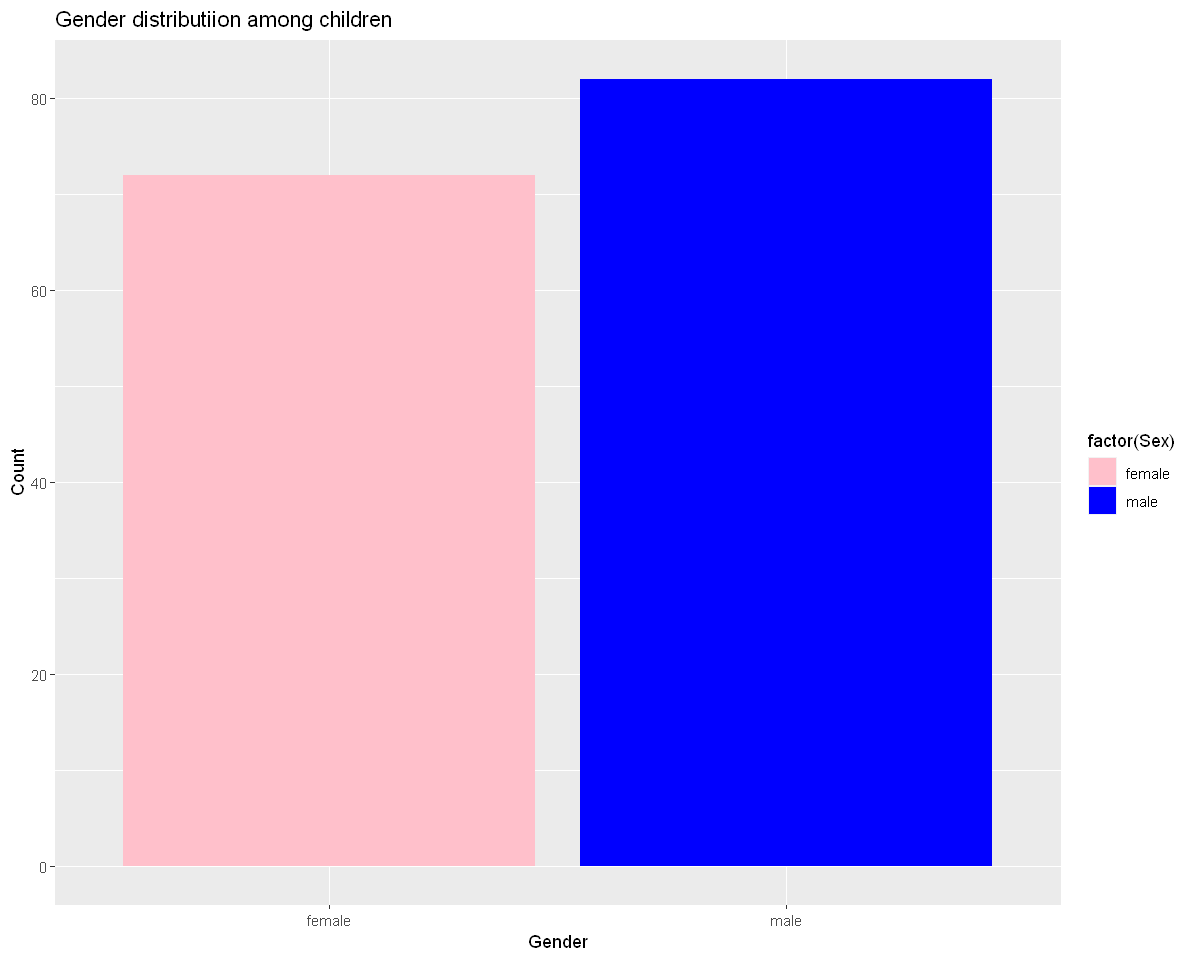

In [168]:
ggplot(under_18, aes(x = Sex , fill = factor(Sex))) +
  geom_bar(na.rm = TRUE) +
  labs(title = "Gender distributiion among children", x = "Gender", y = "Count") +
scale_fill_manual(values = c("male" = "blue", "female" = "pink"))



 0  1 
52 61 

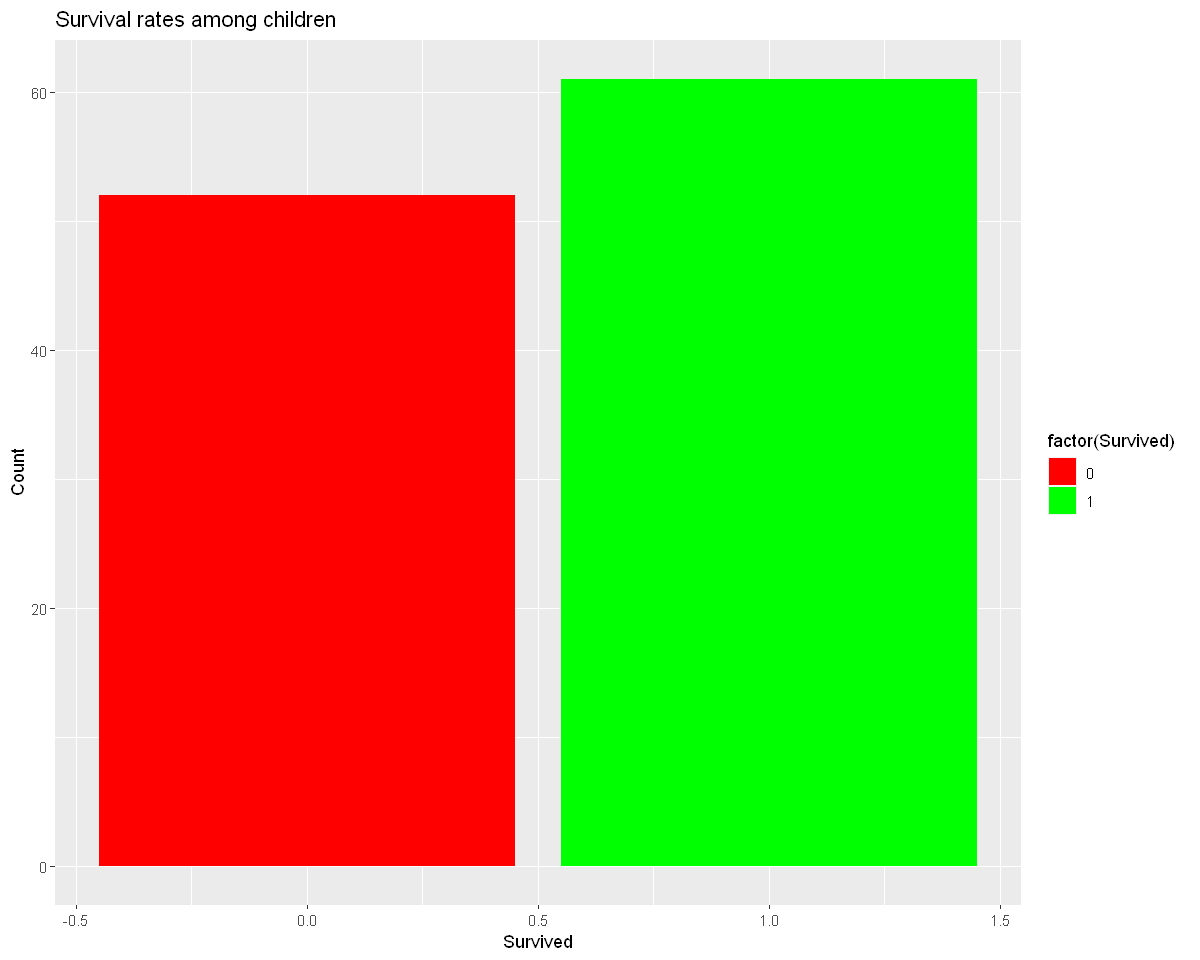

In [169]:
ggplot(under_18, aes(x = Survived , fill = factor(Survived))) +
  geom_bar(na.rm = TRUE) +
  labs(title = "Survival rates among children", x = "Survived", y = "Count") +
scale_fill_manual(values = c("0" = "red", "1" = "green"))


table(under_18$Survived)

### Correlation analysis

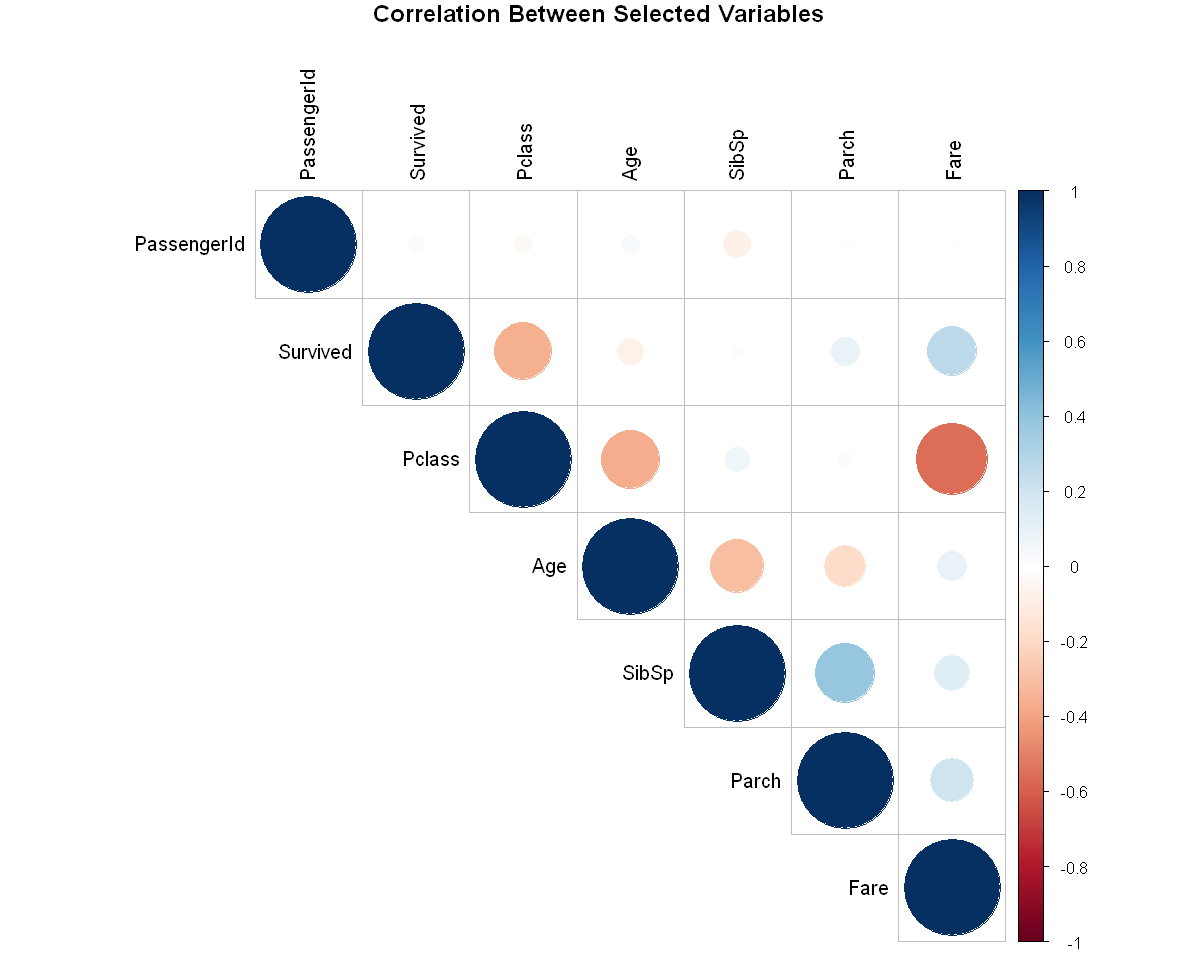

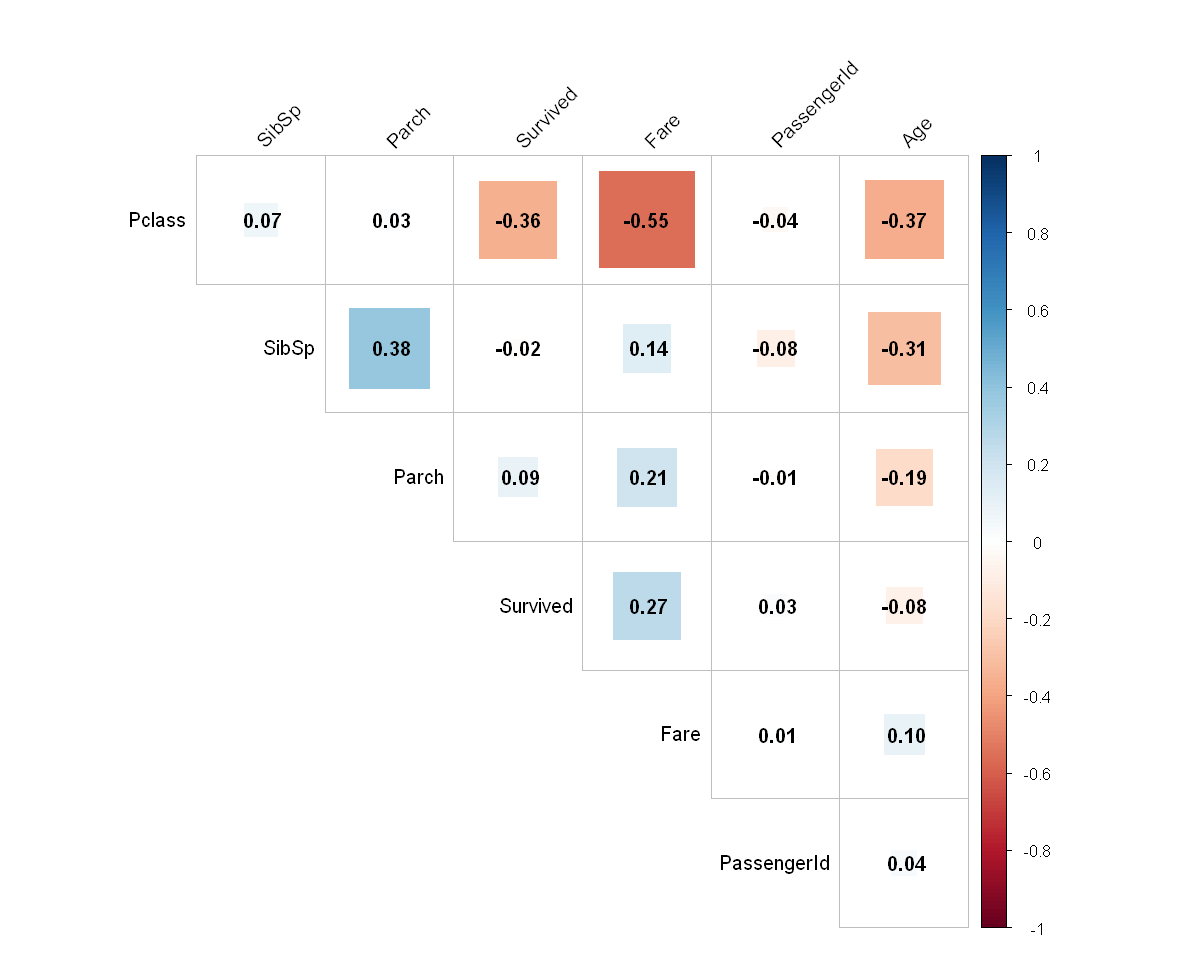

In [170]:
df_numericalvars <- titanic[, sapply(titanic, is.numeric)]  # Select numerical columns
corr <- cor(df_numericalvars, use = "complete.obs")  # Calculate the correlation matrix

# Plot the correlation matrix using corrplot
corrplot(corr, method = "circle", type = "upper", tl.col = "black", 
         title = "Correlation Between Selected Variables", mar = c(0, 0, 1, 0))


#### number 2 attempt at the corrplot, this gives more info with the second correlation plot

cor_matrix <- cor(df_numericalvars, use = 'complete.obs')

# Correlation plot
corrplot(cor_matrix,
         method = 'square',
         type = 'upper',
         diag = FALSE,
         order = 'hclust',
         tl.col = 'black',
         tl.srt = 45,
         addCoef.col = 'black'
         )

Negative correlation between fare and Passenger class is clear as class 3 means lesser fares and class 1 is higher fares. There is a slightly positive correlation between siblings and spouses being on board and parents/children being on board as families travel together. As we've found more passengers from class 1 were saved than from class 3, it can explain the negative correlation between pclass and survived. 

Older passengers have choosen Pclass1 and younger passengers have generally taken class 3 tickets. this explains the negative correlation between age and passenger class.

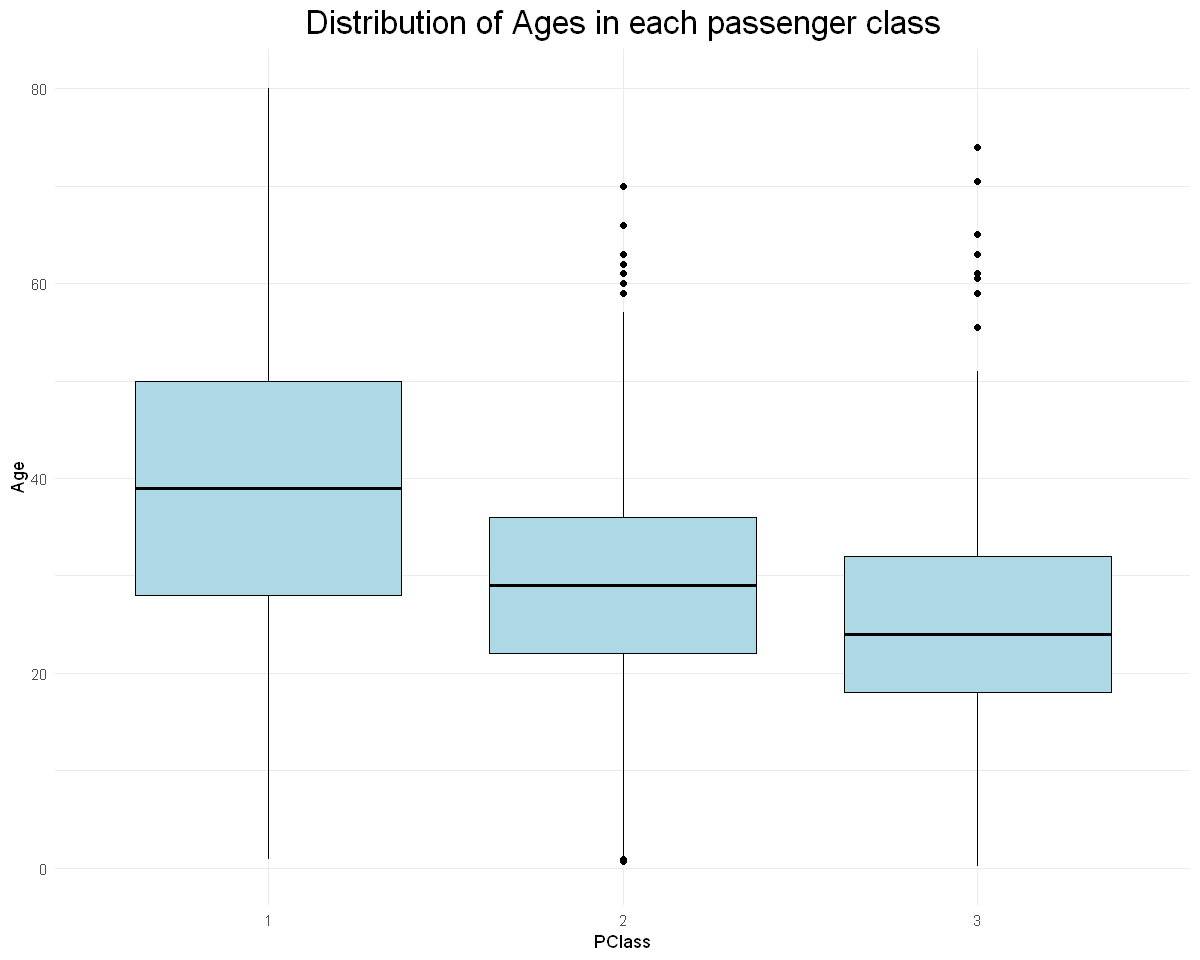

In [171]:
ggplot(titanic, aes(x = factor(Pclass), y = Age)) +
  geom_boxplot(fill = "lightblue", color = "black", na.rm = TRUE) +  # Boxplot with light blue fill and black borders
  labs(title = "Distribution of Ages in each passenger class", 
       x = "PClass", y = "Age") +
  theme_minimal() +
  theme(plot.title = element_text(hjust = 0.5, vjust = 1.02, size=20))

It is seen that more older passnegers have choosen passenger class 1. Also class 1 passengers show a larger age distribution compared to class 2 and 3. Class 3 passengers are generally younger with their median age being around 25.

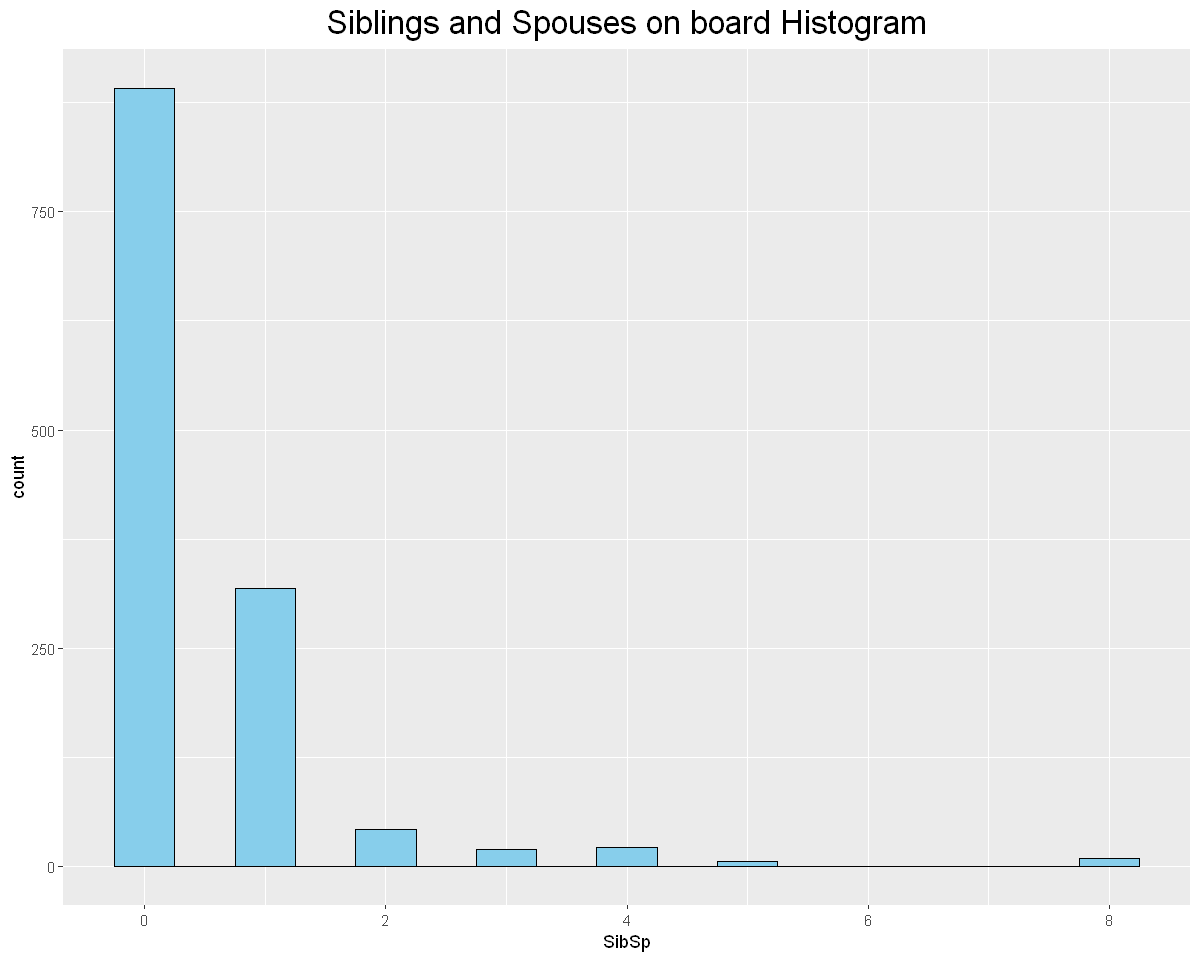

In [172]:
ggplot(titanic, aes(x = SibSp)) + 
      geom_histogram(binwidth = .5, fill = "skyblue", color = "black") +
      labs(title = "Siblings and Spouses on board Histogram")+
theme(plot.title = element_text(hjust = 0.5, vjust = 1.02, size=20))

In [173]:
summary(titanic$SibSp)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.0000  0.4989  1.0000  8.0000 

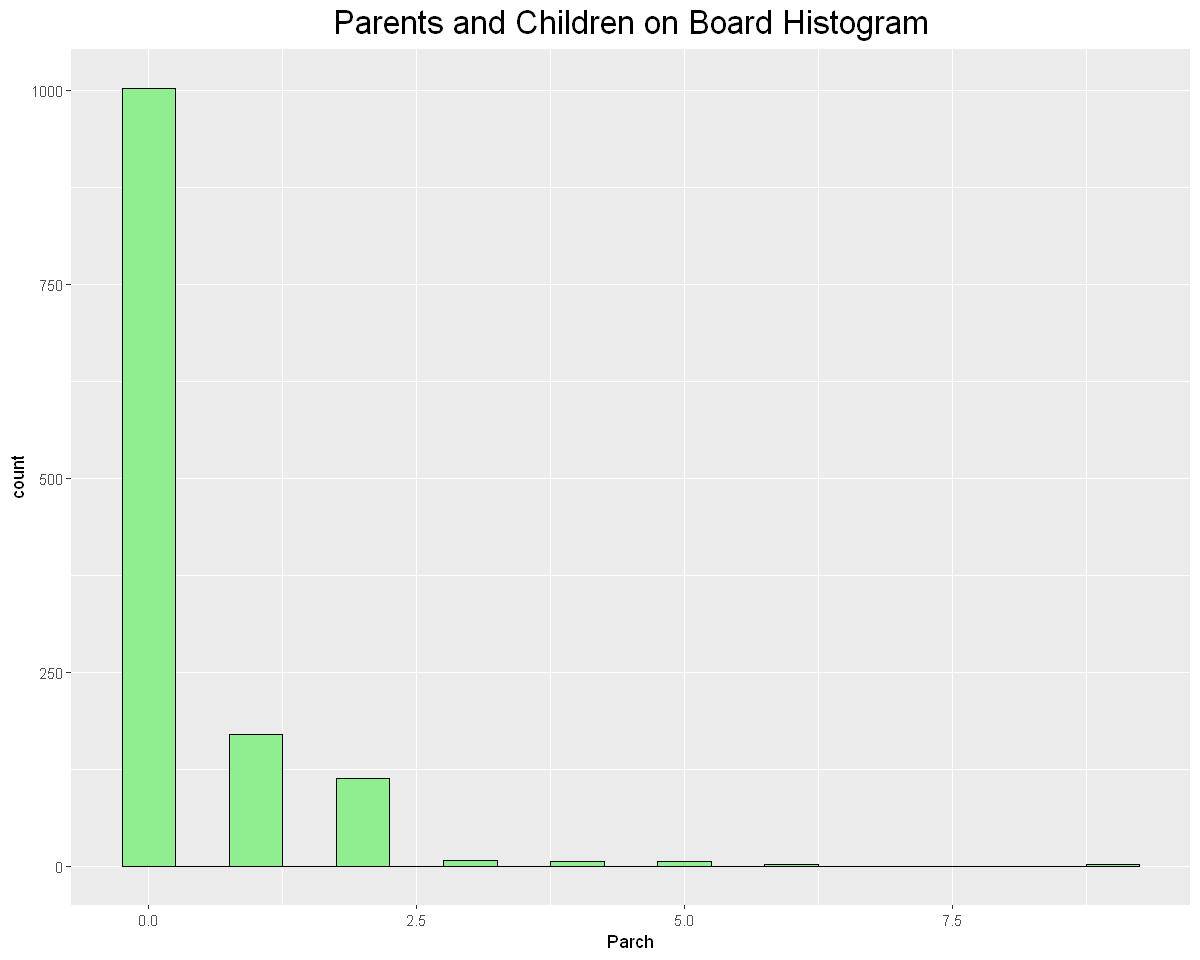

In [174]:
ggplot(titanic, aes(x = Parch)) + 
      geom_histogram(binwidth = .5, fill = "lightgreen", color = "black") +
      labs(title = "Parents and Children on Board Histogram")+
theme(plot.title = element_text(hjust = 0.5, vjust = 1.02, size=20))

## Data preprocessing

> From here onwards, I'm using the train and testing datasets separately instead of the combined dataset. 

Data cleaning and preprocesssing steps applied


In [175]:
tail(df_train)
tail(df_test)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
886,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39,0,5,382652,29.125,,Q
887,887,0,2,"Montvila, Rev. Juozas",male,27,0,0,211536,13.000,,S
888,888,1,1,"Graham, Miss. Margaret Edith",female,19,0,0,112053,30.000,B42,S
889,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NA,1,2,W./C. 6607,23.450,,S
890,890,1,1,"Behr, Mr. Karl Howell",male,26,0,0,111369,30.000,C148,C
891,891,0,3,"Dooley, Mr. Patrick",male,32,0,0,370376,7.750,,Q


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
413,1304,3,"Henriksson, Miss. Jenny Lovisa",female,28.0,0,0,347086,7.7750,,S
414,1305,3,"Spector, Mr. Woolf",male,NA,0,0,A.5. 3236,8.0500,,S
415,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
416,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,,S
417,1308,3,"Ware, Mr. Frederick",male,NA,0,0,359309,8.0500,,S
418,1309,3,"Peter, Master. Michael J",male,NA,1,1,2668,22.3583,,C


#### Handling missing values

In [176]:
# R identifies missing data through NA. replacing all empty strings with NA
df_train[df_train == ""] <- NA

#missing values in train dataset
colSums(is.na(df_train)) #colsums sums up the true and false values


PassengerId    Survived      Pclass        Name         Sex         Age 
          0           0           0           0           0         177 
      SibSp       Parch      Ticket        Fare       Cabin    Embarked 
          0           0           0           0         687           2

In [177]:
df_test[df_test == ""] <- NA

#missing values in test dataset
colSums(is.na(df_test)) #colsums sums up the true and false values


PassengerId      Pclass        Name         Sex         Age       SibSp 
          0           0           0           0          86           0 
      Parch      Ticket        Fare       Cabin    Embarked 
          0           0           1         327           0

In [178]:
# replacing the missing 2 values of Embarked in train dataset with the mode
embarked_mode <- names(sort(table(df_train$Embarked), decreasing = TRUE))[1] # just getting the number 1 in the ordered list of embarked places
df_train$Embarked[is.na(df_train$Embarked)] <- embarked_mode

##### Handling missing age column

the age column has a significant number of null values in both datasets. to inpute the missing values, many approaches can be followed. we can simply replace all missing values with the mean age. But this won't allow us to capture nuances in the dataset where it's correlated with certain factors such as passenger class. [Correlation analysis](###Correlation-analysis)

Age is most correlated with Passenger class and Siblings/spouses on board. 


In [179]:
# Impute missing Age values based on Pclass and SibSp
df_train_grouped <- df_train %>%
  group_by(Pclass, SibSp)

In [180]:
head(df_train_grouped)

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NA,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NA,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NA,S
6,0,3,"Moran, Mr. James",male,NA,0,0,330877,8.4583,NA,Q


In [181]:
# Replace NA values in Age with the median for each group
df_train_grouped <- df_train_grouped %>%
  mutate(Age = ifelse(is.na(Age), median(Age, na.rm = TRUE), Age))

# Ungroup the data
df_train <- df_train_grouped %>%
  ungroup()

In [182]:
# doing all the above in one operation
df_train <- df_train %>%
  group_by(Pclass, SibSp) %>%
  mutate(Age = ifelse(is.na(Age), median(Age, na.rm = TRUE), Age)) %>%
  ungroup()

In [183]:
df_train <- as.data.frame(df_train)
head(df_train)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,NA,S
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,NA,S
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,C123,S
5,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,NA,S
6,6,0,3,"Moran, Mr. James",male,26,0,0,330877,8.4583,NA,Q


In [184]:
df_train[is.na(df_train$Age),]

df_train[df_train$SibSp==8,]
#thus the values of sibling size 8 are not filled because all the records with 8 siblings are not filled. thus median calculations result in no value.

#looking for other family members/parents
df_train[df_train$Ticket=="CA. 2343",]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
160,160,0,3,"Sage, Master. Thomas Henry",male,NA,8,2,CA. 2343,69.55,NA,S
181,181,0,3,"Sage, Miss. Constance Gladys",female,NA,8,2,CA. 2343,69.55,NA,S
202,202,0,3,"Sage, Mr. Frederick",male,NA,8,2,CA. 2343,69.55,NA,S
325,325,0,3,"Sage, Mr. George John Jr",male,NA,8,2,CA. 2343,69.55,NA,S
793,793,0,3,"Sage, Miss. Stella Anna",female,NA,8,2,CA. 2343,69.55,NA,S
847,847,0,3,"Sage, Mr. Douglas Bullen",male,NA,8,2,CA. 2343,69.55,NA,S
864,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NA,8,2,CA. 2343,69.55,NA,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
160,160,0,3,"Sage, Master. Thomas Henry",male,NA,8,2,CA. 2343,69.55,NA,S
181,181,0,3,"Sage, Miss. Constance Gladys",female,NA,8,2,CA. 2343,69.55,NA,S
202,202,0,3,"Sage, Mr. Frederick",male,NA,8,2,CA. 2343,69.55,NA,S
325,325,0,3,"Sage, Mr. George John Jr",male,NA,8,2,CA. 2343,69.55,NA,S
793,793,0,3,"Sage, Miss. Stella Anna",female,NA,8,2,CA. 2343,69.55,NA,S
847,847,0,3,"Sage, Mr. Douglas Bullen",male,NA,8,2,CA. 2343,69.55,NA,S
864,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NA,8,2,CA. 2343,69.55,NA,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
160,160,0,3,"Sage, Master. Thomas Henry",male,NA,8,2,CA. 2343,69.55,NA,S
181,181,0,3,"Sage, Miss. Constance Gladys",female,NA,8,2,CA. 2343,69.55,NA,S
202,202,0,3,"Sage, Mr. Frederick",male,NA,8,2,CA. 2343,69.55,NA,S
325,325,0,3,"Sage, Mr. George John Jr",male,NA,8,2,CA. 2343,69.55,NA,S
793,793,0,3,"Sage, Miss. Stella Anna",female,NA,8,2,CA. 2343,69.55,NA,S
847,847,0,3,"Sage, Mr. Douglas Bullen",male,NA,8,2,CA. 2343,69.55,NA,S
864,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NA,8,2,CA. 2343,69.55,NA,S


From the surname "Sage" in all these records infer they actually are from the same family.the ticket numbers and embarked locations all match. Parch=2 can mean these are under 18 minors who are probablty travelling with their parents. Master and Miss titles in the records further clear that these were children of the same family. 

In [185]:
# looking for other family members in the test dataset
df_test[(df_test$Ticket=="CA. 2343"),]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
189,1080,3,"Sage, Miss. Ada",female,NA,8,2,CA. 2343,69.55,NA,S
343,1234,3,"Sage, Mr. John George",male,NA,1,9,CA. 2343,69.55,NA,S
361,1252,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,NA,S
366,1257,3,"Sage, Mrs. John (Annie Bullen)",female,NA,1,9,CA. 2343,69.55,NA,S


therefore this is the data from a large family of 11. 9 children and 2 parents. Sadly our data suggests this entire family has perished from the titanic disaster. 
Only the age of one boy in the test dataset is available. 

we can replace the ages by copying from online sources about this family. Instead, I'll be replacing all Children ages with 14 and both of the parents ages with 45 so we are not doing anything special to this specific family only by replacing each row with real ages. 

Another important finding is how tickets have been issued. Families have been issued the same ticket number and the fare has seeemingly been calculated by diving the entire ticket cost between the number of passengers sharing the ticket. 

In [186]:
df_train$Age[df_train$SibSp == 8] <- 14 #replacing all children's ages with 14
df_test$Age[df_test$SibSp == 8] <- 14 

df_test$Age[df_test$Parch == 9] <- 45  #replacing parent's ages with 45

handling missing ages in test data

In [187]:
df_test <- df_test %>%
  group_by(Pclass, SibSp) %>%
  mutate(Age = ifelse(is.na(Age), median(Age, na.rm = TRUE), Age)) %>%
  ungroup()

In [188]:
df_test[is.na(df_test$Age),]

PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
<int>,<int>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>


In [189]:
#replacing the missing value in fare column in test data
df_test$Fare[is.na(df_test$Fare)] <- median(df_train$Fare, na.rm = TRUE)

In [190]:
df_test<-as.data.frame(df_test) # converting it from a tibble to a df

#### Encoding categorical variables

In [191]:
#label encoding for sex
df_train$Sex <- ifelse(df_train$Sex == "male", 1, 0)
df_test$Sex <- ifelse(df_test$Sex == "male", 0, 1)

#then converting them to factors 
df_train$Sex<- factor(df_train$Sex) 
df_test$Sex<- factor(df_test$Sex) #converting them to factors is not necessary, but tree based models handle categorical data differently

Tree based models can detect and utilize the ordinal relationship in Pclass if it's encoded as an ordered factor or numeric values.

In [192]:
#converting passenger class to an ordinal factor(categorical column) because they have a  natural order in terms of socio-economic status,
df_train$Pclass <- factor(df_train$Pclass, levels = c(1, 2, 3), ordered = TRUE)
df_test$Pclass <- factor(df_test$Pclass, levels = c(1, 2, 3), ordered = TRUE)

In [193]:
head(df_test)
head(df_train)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<ord>,<chr>,<fct>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,892,3,"Kelly, Mr. James",0,34.5,0,0,330911,7.8292,NA,Q
2,893,3,"Wilkes, Mrs. James (Ellen Needs)",1,47.0,1,0,363272,7.0000,NA,S
3,894,2,"Myles, Mr. Thomas Francis",0,62.0,0,0,240276,9.6875,NA,Q
4,895,3,"Wirz, Mr. Albert",0,27.0,0,0,315154,8.6625,NA,S
5,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",1,22.0,1,1,3101298,12.2875,NA,S
6,897,3,"Svensson, Mr. Johan Cervin",0,14.0,0,0,7538,9.2250,NA,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
,<int>,<int>,<ord>,<chr>,<fct>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>
1,1,0,3,"Braund, Mr. Owen Harris",1,22,1,0,A/5 21171,7.2500,NA,S
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",0,38,1,0,PC 17599,71.2833,C85,C
3,3,1,3,"Heikkinen, Miss. Laina",0,26,0,0,STON/O2. 3101282,7.9250,NA,S
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,1,0,113803,53.1000,C123,S
5,5,0,3,"Allen, Mr. William Henry",1,35,0,0,373450,8.0500,NA,S
6,6,0,3,"Moran, Mr. James",1,26,0,0,330877,8.4583,NA,Q


#### Feature Engineering

In [194]:
# feature engineering

# creating a column as family size by combining the number of siblings/spouse on board and the number of parents/children. plus 1+ to include the passenger.
df_train$FamilySize <- df_train$SibSp + df_train$Parch + 1
df_test$FamilySize <- df_test$SibSp + df_test$Parch + 1

##### extracting title from the name column

In [195]:
# Extract title using a regular expression
df_train$Title <- sub(".*?,\\s*(.*?)\\..*", "\\1", df_train$Name)
df_test$Title <- sub(".*?,\\s*(.*?)\\..*", "\\1", df_test$Name)

head(df_train)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,Title
,<int>,<int>,<ord>,<chr>,<fct>,<dbl>,<int>,<int>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>
1,1,0,3,"Braund, Mr. Owen Harris",1,22,1,0,A/5 21171,7.2500,NA,S,2,Mr
2,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",0,38,1,0,PC 17599,71.2833,C85,C,2,Mrs
3,3,1,3,"Heikkinen, Miss. Laina",0,26,0,0,STON/O2. 3101282,7.9250,NA,S,1,Miss
4,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35,1,0,113803,53.1000,C123,S,2,Mrs
5,5,0,3,"Allen, Mr. William Henry",1,35,0,0,373450,8.0500,NA,S,1,Mr
6,6,0,3,"Moran, Mr. James",1,26,0,0,330877,8.4583,NA,Q,1,Mr



   Col   Dona     Dr Master   Miss     Mr    Mrs     Ms    Rev 
     2      1      1     21     78    240     72      1      2 

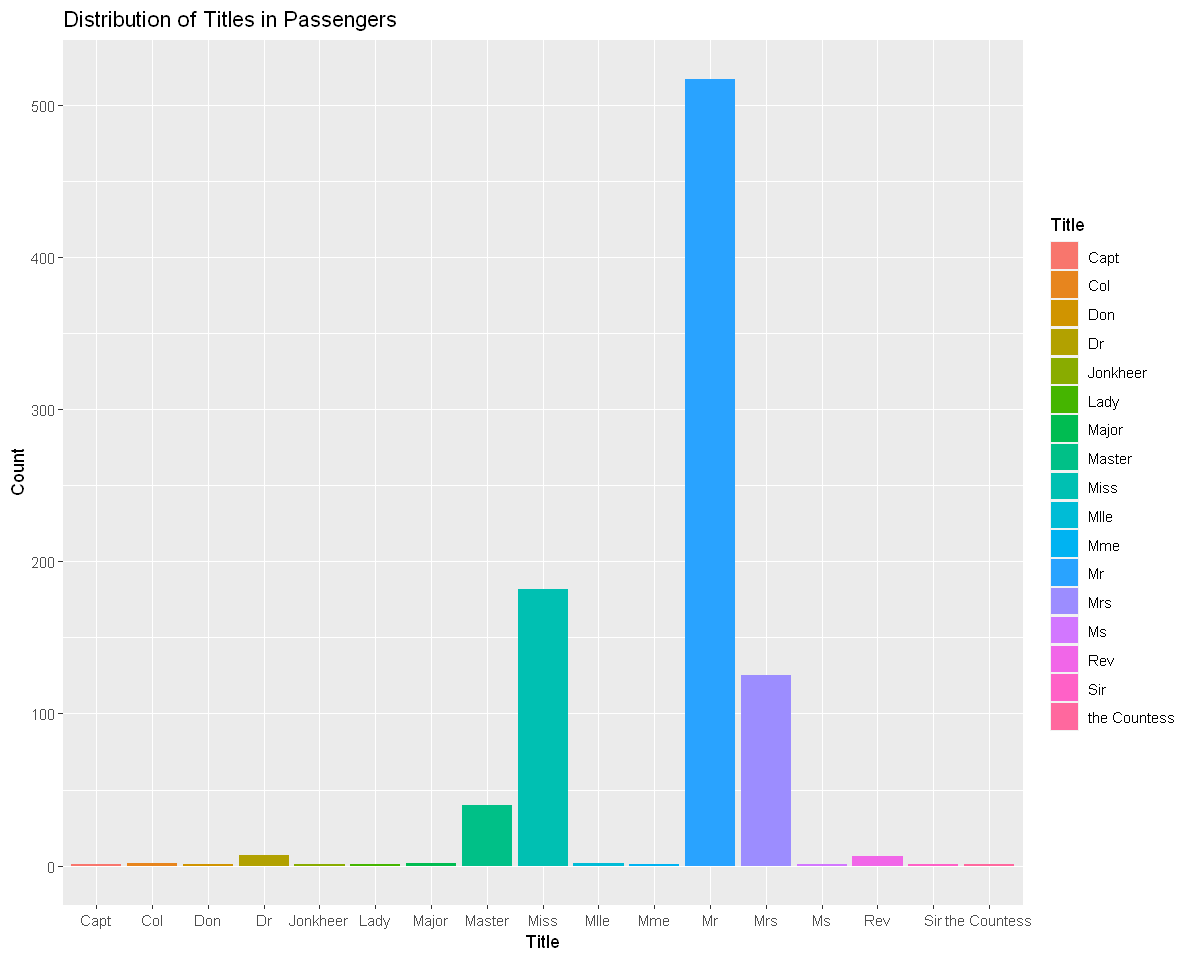

In [196]:
table(df_test$Title)

ggplot(df_train, aes(x = Title, fill = Title)) +
  geom_bar() +
  labs(title = "Distribution of Titles in Passengers", x = "Title", y = "Count")


mme is the frech equivalent of Mrs. and mlle is the french equivalent of Miss. Ms also meams miss. 
So we will have to replace those with Mrs. and Miss

In [197]:
#combining infrequent miss and mrs columns in to one
df_train$Title <- ifelse(df_train$Title %in% c("Mlle", "Ms"), "Miss", df_train$Title)
df_train$Title <- ifelse(df_train$Title %in% c("Mme"), "Mrs", df_train$Title)

df_test$Title <- ifelse(df_test$Title %in% c("Mlle", "Ms"), "Miss", df_test$Title)
df_test$Title <- ifelse(df_test$Title %in% c("Mme"), "Mrs", df_test$Title)


In [198]:
# Count title frequency and filter based on a threshold
title_counts <- df_train %>%
  count(Title) %>%
  mutate(is_infrequent = n < 10) %>%   # Set a threshold, e.g., less than 10 occurrences
  select(-n)

# Join the frequency info back to the original dataframe
df_train <- df_train %>%
  left_join(title_counts, by = "Title") %>%
  mutate(Title = ifelse(is_infrequent, "Other", Title)) %>%
  select(-is_infrequent)  # Drop the temporary 'is_infrequent' column

In [199]:
# for the test dataset

title_counts <- df_test %>%
  count(Title) %>%
  mutate(is_infrequent = n < 10) %>%   # Set a threshold, e.g., less than 10 occurrences
  select(-n)

# Join the frequency info back to the original dataframe
df_test <- df_test %>%
  left_join(title_counts, by = "Title") %>%
  mutate(Title = ifelse(is_infrequent, "Other", Title)) %>%
  select(-is_infrequent)  # Drop the temporary 'is_infrequent' column

df_test$Title=as.factor(df_test$Title)
df_train$Title=as.factor(df_train$Title)

In [200]:
table(df_test$Title)


Master   Miss     Mr    Mrs  Other 
    21     79    240     72      6 

#### Dropping unnecessary columns

In [201]:
df_train <- select(df_train, -Ticket, -Name, -Cabin) # dropping the columns from the dataset
df_test <- select(df_test, -Ticket, -Cabin, -Name) 

In [202]:
head(df_train)
head(df_test)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Title
,<int>,<int>,<ord>,<fct>,<dbl>,<int>,<int>,<dbl>,<chr>,<dbl>,<fct>
1,1,0,3,1,22,1,0,7.2500,S,2,Mr
2,2,1,1,0,38,1,0,71.2833,C,2,Mrs
3,3,1,3,0,26,0,0,7.9250,S,1,Miss
4,4,1,1,0,35,1,0,53.1000,S,2,Mrs
5,5,0,3,1,35,0,0,8.0500,S,1,Mr
6,6,0,3,1,26,0,0,8.4583,Q,1,Mr


,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,Title
,<int>,<ord>,<fct>,<dbl>,<int>,<int>,<dbl>,<chr>,<dbl>,<fct>
1,892,3,0,34.5,0,0,7.8292,Q,1,Mr
2,893,3,1,47.0,1,0,7.0000,S,2,Mrs
3,894,2,0,62.0,0,0,9.6875,Q,1,Mr
4,895,3,0,27.0,0,0,8.6625,S,1,Mr
5,896,3,1,22.0,1,1,12.2875,S,3,Mrs
6,897,3,0,14.0,0,0,9.2250,S,1,Mr


## Model Building

In [203]:
# install.packages("randomForest")
# suppressMessages(library(randomForest))

In [204]:
target <- "Survived"
predictors <- setdiff(names(df_train), target)

In [205]:
predictors

[1] "PassengerId" "Pclass"      "Sex"         "Age"         "SibSp"      
 [6] "Parch"       "Fare"        "Embarked"    "FamilySize"  "Title"

In [206]:
train_control <- trainControl(
  method = "cv",          
  number = 10,            # Number of folds
  classProbs = FALSE,      
  summaryFunction = defaultSummary  
)

In [207]:
#converting the survived column to a factor
# df_train[[target]] <- factor(df_train[[target]], levels = c(0, 1), labels = c("No", "Yes"))

It's always good to assign human-readable factor levels instead of numerical ones when working with classification models in R.(target) has levels 0 and 1, which are not valid R variable names. When caret::train() tries to generate class probabilities, it automatically renames them to X0 and X1, which can cause issues.

In [208]:
model <- train(
  x = df_train[, predictors],
  y = as.factor(df_train[[target]]),
  method = "rf",
  trControl = train_control,
  metric = "Accuracy"  
)

In [209]:
colSums(is.na(df_test))


PassengerId      Pclass         Sex         Age       SibSp       Parch 
          0           0           0           0           0           0 
       Fare    Embarked  FamilySize       Title 
          0           0           0           0

In [210]:
test_predictions <- predict(model, newdata = df_test)

In [211]:
head(test_predictions)

[1] 0 0 0 0 0 0
Levels: 0 1

In [212]:
submission <- data.frame(PassengerId = df_test$PassengerId, Survived = test_predictions)
write.csv(submission, "submission.csv", row.names = FALSE)
